In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('data_science_job.csv')

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [6]:
df.isnull().mean()*100 # percent data missing nikala

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [8]:
df.shape

(19158, 13)

In [13]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

In [14]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [15]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
15149,0.855,no_enrollment,Graduate,11.0,50.0
16273,0.920,no_enrollment,Graduate,1.0,10.0
6790,0.738,no_enrollment,Masters,11.0,37.0
15159,0.624,no_enrollment,High School,6.0,126.0
13106,0.624,Full time course,Graduate,1.0,21.0


In [16]:
len(df[cols].dropna())/ len(df)

0.8968577095730244

In [17]:
# after removing all the missing rows form ye vale columns, still we will be having 89 percent data 

In [18]:
new_df = df[cols].dropna()

In [19]:
new_df.shape

(17182, 5)

In [20]:
df.shape

(19158, 13)

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

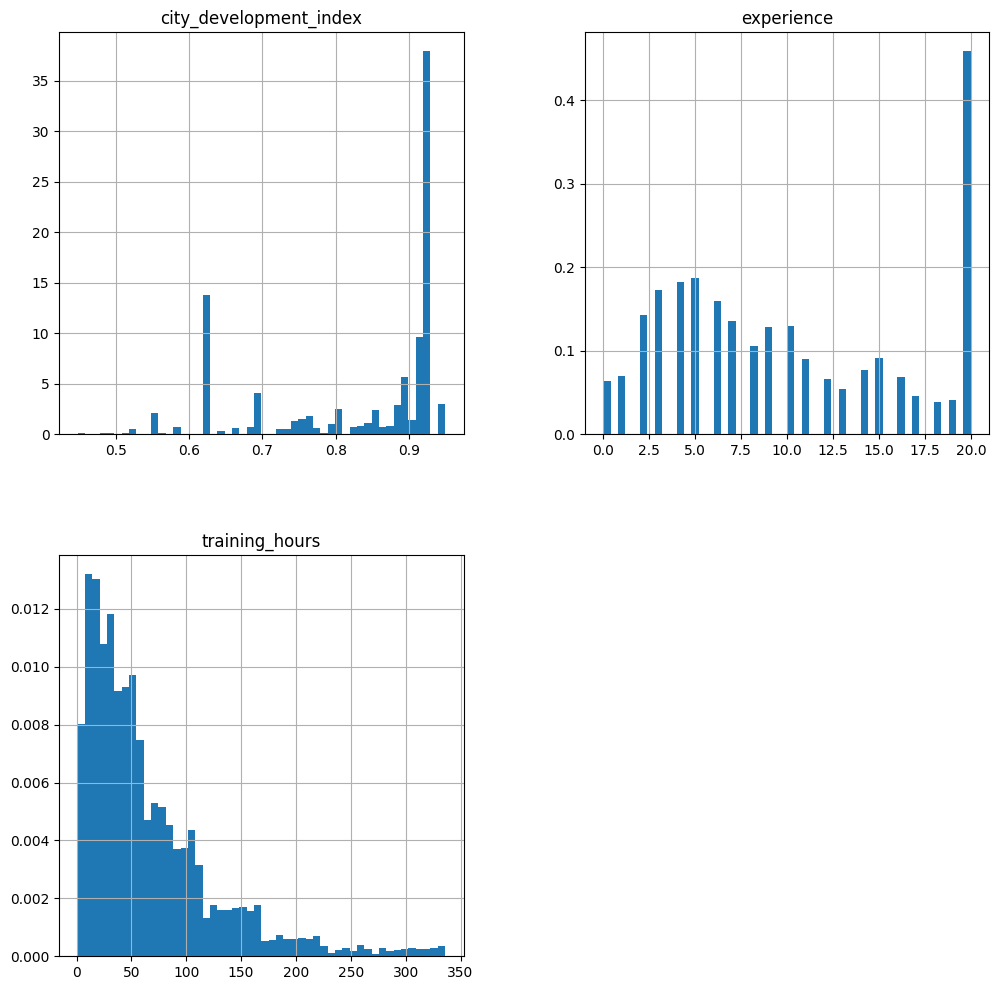

In [21]:
new_df.hist(bins = 50, density = True, figsize = (12,12))

<Axes: >

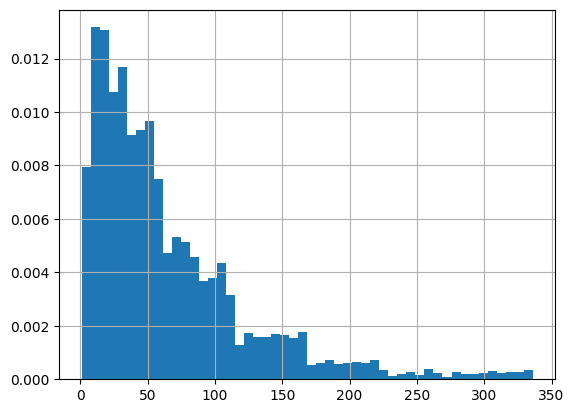

In [24]:
df['training_hours'].hist(bins = 50, density = True)

<Axes: >

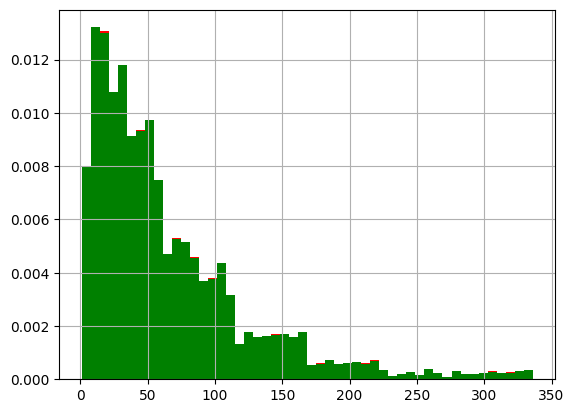

In [25]:
df['training_hours'].hist(bins = 50, density = True, color = 'red')
new_df['training_hours'].hist(bins = 50, density = True, color = 'green')

<Axes: >

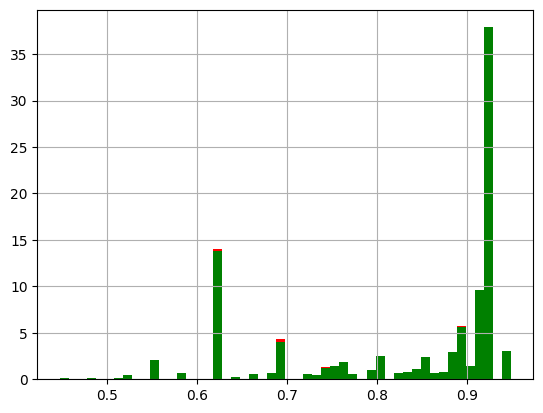

In [26]:
df['city_development_index'].hist(bins = 50, density = True, color = 'red')
new_df['city_development_index'].hist(bins = 50, density = True, color = 'green')

<Axes: >

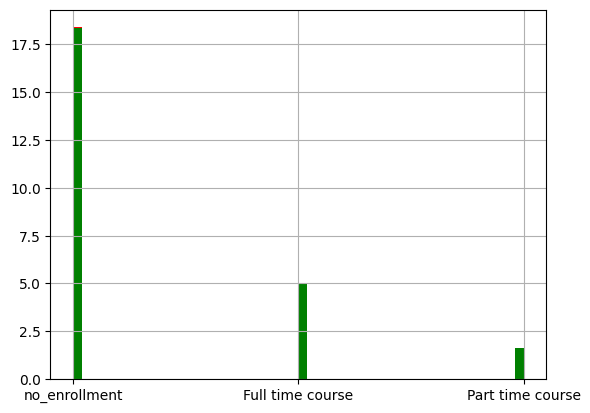

In [29]:
df['enrolled_university'].hist(bins = 50, density = True, color = 'red')
new_df['enrolled_university'].hist(bins = 50, density = True, color = 'green')

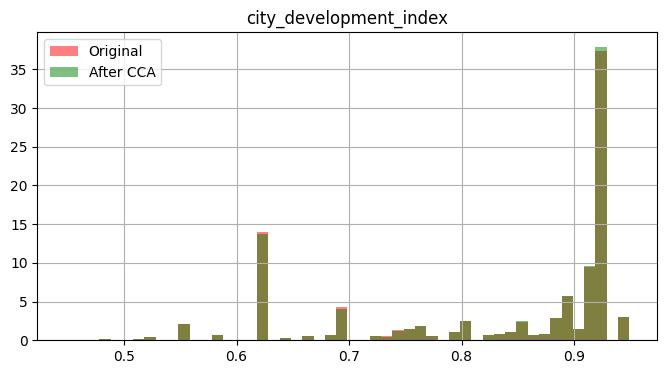

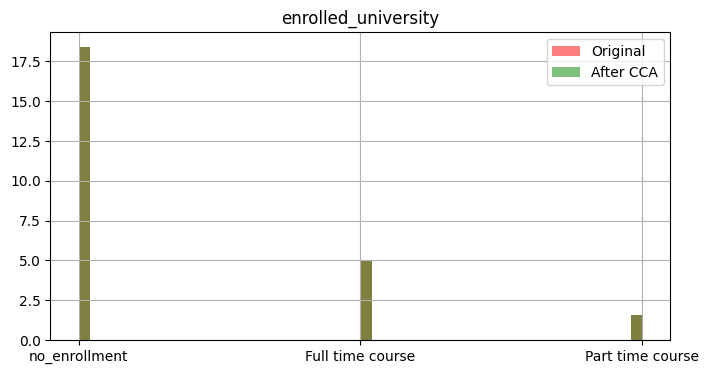

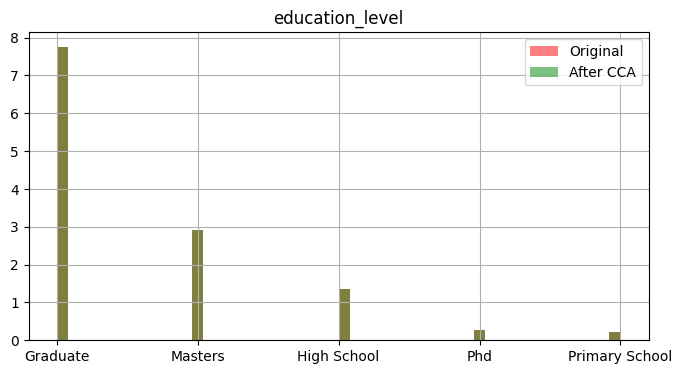

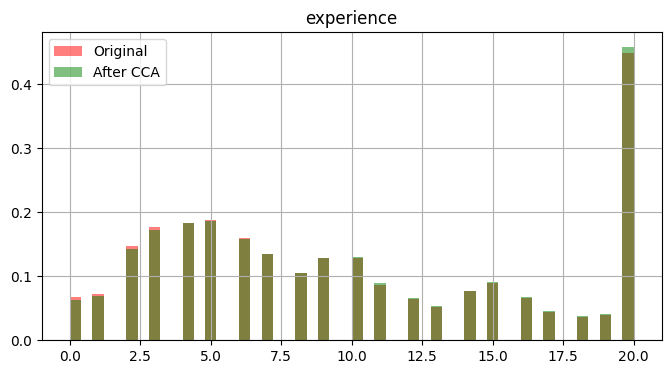

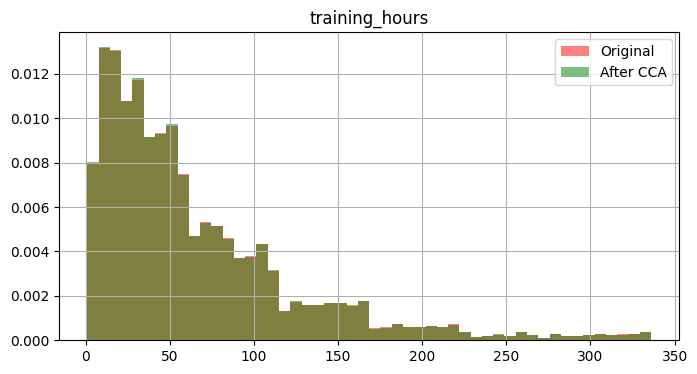

In [31]:
import matplotlib.pyplot as plt

for col in cols:

    plt.figure(figsize=(8,4))

    df[col].hist(
        bins=50,
        density=True,
        color='red',
        alpha=0.5,
        label='Original'
    )

    new_df[col].hist(
        bins=50,
        density=True,
        color='green',
        alpha=0.5,
        label='After CCA'
    )

    plt.title(col)
    plt.legend()
    plt.show()

In [32]:
# ratios of each column jisme we have applied the cca should be same before and after the 

In [33]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [34]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
